# XGBoost(eXtreme Gradient Boosting)

- 과적합 방지가 가능한 규제가 포함되어 있다.
- CART(Classification And Regression Tree)를 기반으로 하므로 분류와 회귀 둘 다 가능하다.
- 조기 종료(early stopping)을 제공한다.
- 앙상블 부스팅의 특징인 가중치 부여를 경사하강법(Gradient descent)으로 한다.

In [1]:
# xgboost 설치
# pip install xgboost
# sklearn에 포함되어 있지 않음

# XGBoost 버전 확인
import xgboost

print(xgboost.__version__)

3.3.0


### 위스콘신 유방암 예측

In [2]:
import pandas as pd

from sklearn import set_config
set_config(display='text')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

In [3]:
# load_breast_cancer 데이터 불러옴

dataset = load_breast_cancer()

X_features = dataset.data  # 학습 데이터
y_label = dataset.target  # 정답 데이터


In [ ]:
cancer_df = pd.DataFrame(data=X_features, columns=dataset.feature_names)  # feature_names 컬럼명
cancer_df['target'] = y_label
cancer_df.head()

In [6]:
print(dataset.target_names)
print(cancer_df['target'].value_counts())

['malignant' 'benign']
target
1    357
0    212
Name: count, dtype: int64


In [ ]:
# 전처리 과정
X_features = cancer_df.iloc[:, :-1]  # 전체 레코드를 -1직전 까지 가져옴, 정답데이터 직전까지, iloc : 0, 1, 2, .. index접근  loc : 컬럼명으로 접근
y_label = cancer_df.iloc[:, -1] # 정답 데이터

# 전체 데이터 중 80%는 학습 데이터, 20%는 테스트용 데이터 추출
X_train, X_test, y_train, y_test = train_test_split(X_features, y_label, \
                                                    test_size=0.2, random_state=156)

# 위에서 만든 X_train, y_train을 다시 쪼개서 90%는 학습용으로, 10%는 검증용 데이터로 분리
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, \
                                                    test_size=0.1, random_state=156)

print(X_train.shape, X_test.shape)
print(X_tr.shape, X_val.shape)
# print(X_tr)

# (455, 30) (114, 30) 테스트 114
# (409, 30) (46, 30) 학습용 409, X_val(검증용 46)

(455, 30) (114, 30)
(409, 30) (46, 30)


### 파이썬 래퍼 XGBoost 적용

In [ ]:
import xgboost as xgb
from xgboost import plot_importance
import numpy as np

dtr = xgb.DMatrix(data=X_tr, label=y_tr)  # X_tr(학습용 409개 데이터), y_tr(학습용 정답 데이터)
dval = xgb.DMatrix(data=X_val, label=y_val)  # X_val(검증용 데이터), y_val(검증용 정답 데이터)
dtest = xgb.DMatrix(data=X_test, label=y_test) # X_test 태스터 데이터, 테스터용 정답 데이터

In [ ]:
# Hyper 파라미터(튜닝)
# 의사결정 알고리즘에 최적화(과적합 방지가 가능한 규제 포함) 

params = {'max_depth':3, 'eta':0.05, 'objective':'binary:logistic', 
          'eval_metric':'logloss'}  # binary:logistic(바이너리의 로지스틱 알고리즘 적용)
num_rounds = 400

In [ ]:
# 학습 데이터 셋은 'train' 또는 평가 데이터 셋은 'eval'로 명기
eval_list = [(dtr, 'train'), (dval, 'eval')]

# 하이퍼 파라미터와 early stopping 파라미터를 train() 함수의 파라미터 전달
# 학습해라 : sklearn의 fit()이 아닌 train()으로 제공, dtrain : 학습용 데이터, early_stopping_rounds : 조기종료 계산
xgb_model = xgb.train(params=params, dtrain=dtr, num_boost_round=num_rounds,
                      early_stopping_rounds=50, evals=eval_list)    

# 학습을 하면 할수록 정확도가 높아지다가 더이상의 개선이 없으면 조기종료

[0]	train-logloss:0.62473	eval-logloss:0.63225
[1]	train-logloss:0.58662	eval-logloss:0.60730
[2]	train-logloss:0.55210	eval-logloss:0.58562
[3]	train-logloss:0.52058	eval-logloss:0.56615
[4]	train-logloss:0.49155	eval-logloss:0.54542
[5]	train-logloss:0.46491	eval-logloss:0.53043
[6]	train-logloss:0.43969	eval-logloss:0.51101
[7]	train-logloss:0.41648	eval-logloss:0.49373
[8]	train-logloss:0.39503	eval-logloss:0.47735
[9]	train-logloss:0.37517	eval-logloss:0.46266
[10]	train-logloss:0.35673	eval-logloss:0.44940
[11]	train-logloss:0.33938	eval-logloss:0.43843
[12]	train-logloss:0.32276	eval-logloss:0.42597
[13]	train-logloss:0.30774	eval-logloss:0.41552
[14]	train-logloss:0.29356	eval-logloss:0.40645
[15]	train-logloss:0.27989	eval-logloss:0.39635
[16]	train-logloss:0.26709	eval-logloss:0.38696
[17]	train-logloss:0.25531	eval-logloss:0.37957
[18]	train-logloss:0.24381	eval-logloss:0.37218
[19]	train-logloss:0.23343	eval-logloss:0.36735
[20]	train-logloss:0.22322	eval-logloss:0.36096
[2

In [16]:
# 예측
pred_probs = xgb_model.predict(dtest) # dtest 20%의 데이터
np.round(pred_probs[:10], 3)

array([0.933, 0.006, 0.687, 0.123, 0.974, 0.999, 0.998, 0.998, 0.996,
       0.001], dtype=float32)

In [17]:
# 예측 확률이 0.5보다 크면 1, 그렇지 않으면 0으로 예측값을 결정하여 list 객체인 predicted에 저장
predicted = [1 if x > 0.5 else 0 for x in pred_probs]
print(predicted[:10])

[1, 0, 1, 0, 1, 1, 1, 1, 1, 0]


### 성능 평가

In [18]:
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score  # 정밀도, 재현율
from sklearn.metrics import f1_score, roc_auc_score

def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    
    # ROC_AUC 추가
    # 시각화
    roc_auc = roc_auc_score(y_test, pred_proba)  # pred_proba : 예측값
    print('오차 행렬')
    print(confusion)
    print('정확도:{0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f}, f1-score: {3:.4f}, AUC: {4:.4f}'.format(accuracy, \
                                                precision, recall, f1, roc_auc))

In [19]:
get_clf_eval(y_test, predicted, pred_probs)

오차 행렬
[[35  2]
 [ 2 75]]
정확도:0.9649, 정밀도: 0.9740, 재현율: 0.9740, f1-score: 0.9740, AUC: 0.9947


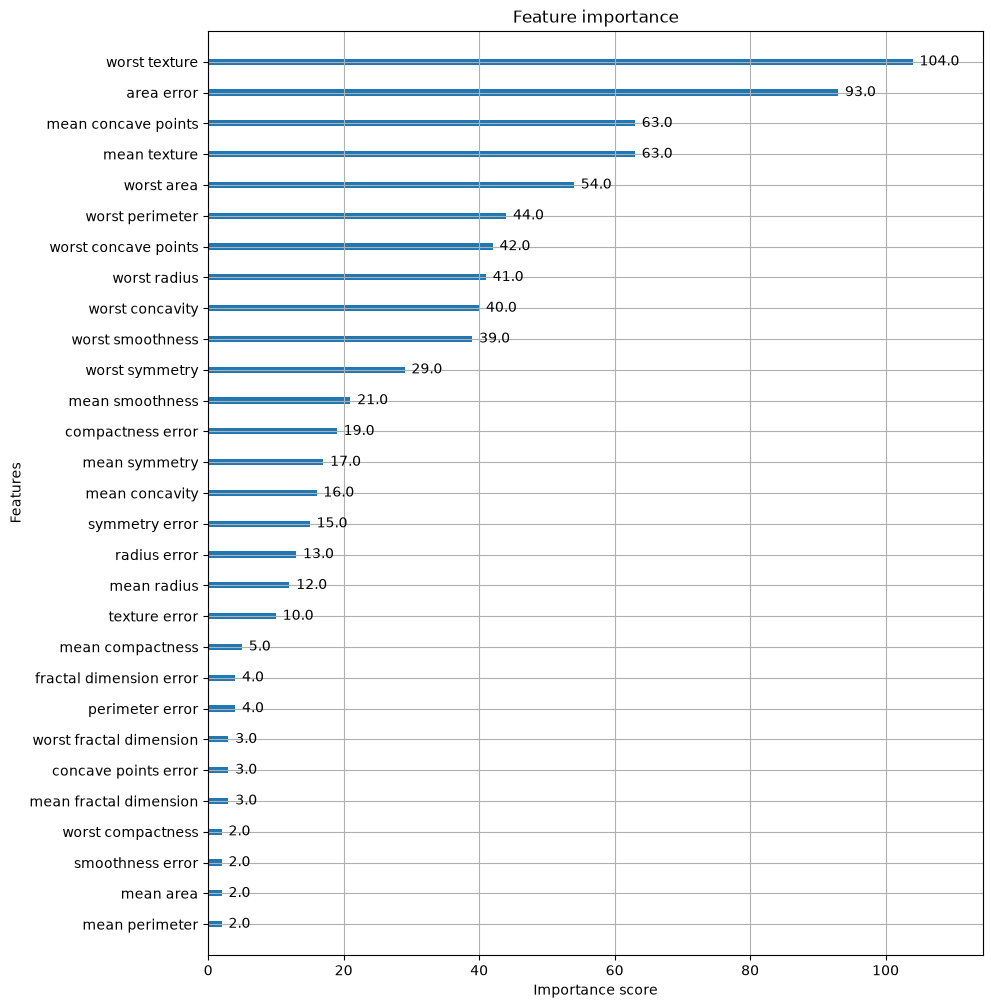

In [ ]:
import matplotlib.pyplot as plt
 
fig, ax = plt.subplots(figsize=(10, 12))
plot_importance(xgb_model, ax=ax)  # plot_importance
plt.savefig('xgb_feature_importance.tif', format='tif', dpi=300)

### 사이킷런 래퍼 XGBoost의 적용

In [ ]:
from xgboost import XGBClassifier   # XGBClassifier : sklearn의 클래스


In [24]:
# sklearn
# num_boost_round=num_rounds, learning_rate : 학습율(모델 학습 반복), max_depth : 과대적합 발생 설정
# Hyper parameter 튜닝
xgb_wrapper = XGBClassifier(n_estimators=400,learning_rate=0.1, max_depth=3)  
xgb_wrapper.fit(X_train, y_train)  # sklearn 모듈은 fit() 함수, 학습용 데이터와 정답

# 예측
w_preds = xgb_wrapper.predict(X_test)
w_preds_proba = xgb_wrapper.predict_proba(X_test)[:, 1]  # predict_proba() : 계산된 확률 값

In [17]:
get_clf_eval(y_test, w_preds, w_preds_proba)

오차 행렬
[[35  2]
 [ 1 76]]
정확도:0.9737, 정밀도: 0.9744, 재현율: 0.9870, f1-score: 0.9806, AUC: 0.9954


In [ ]:
# 조기종료(early stopping)을 제공

xgb_wrapper = XGBClassifier(n_estimators=400, learning_rate=0.1, max_depth=3, eval_metric='logloss', early_stopping_rounds=50)
evals = [(X_test, y_test)]
xgb_wrapper.fit(X_train, y_train, eval_set=evals, verbose=True)
w_preds = xgb_wrapper.predict(X_test)
w_preds_proba = xgb_wrapper.predict_proba(X_test)[:, 1]

[0]	validation_0-logloss:0.56683
[1]	validation_0-logloss:0.50922
[2]	validation_0-logloss:0.45864
[3]	validation_0-logloss:0.41838
[4]	validation_0-logloss:0.38437
[5]	validation_0-logloss:0.35195
[6]	validation_0-logloss:0.32652
[7]	validation_0-logloss:0.30091
[8]	validation_0-logloss:0.28150
[9]	validation_0-logloss:0.26302
[10]	validation_0-logloss:0.24877
[11]	validation_0-logloss:0.23124
[12]	validation_0-logloss:0.21933
[13]	validation_0-logloss:0.20505
[14]	validation_0-logloss:0.19400
[15]	validation_0-logloss:0.18174
[16]	validation_0-logloss:0.17203
[17]	validation_0-logloss:0.16280
[18]	validation_0-logloss:0.15588
[19]	validation_0-logloss:0.14971


[20]	validation_0-logloss:0.14418
[21]	validation_0-logloss:0.13650
[22]	validation_0-logloss:0.13049
[23]	validation_0-logloss:0.12617
[24]	validation_0-logloss:0.12168
[25]	validation_0-logloss:0.11868
[26]	validation_0-logloss:0.11532
[27]	validation_0-logloss:0.11300
[28]	validation_0-logloss:0.11006
[29]	validation_0-logloss:0.10661
[30]	validation_0-logloss:0.10363
[31]	validation_0-logloss:0.09986
[32]	validation_0-logloss:0.09713
[33]	validation_0-logloss:0.09435
[34]	validation_0-logloss:0.09261
[35]	validation_0-logloss:0.09049
[36]	validation_0-logloss:0.08917
[37]	validation_0-logloss:0.08876
[38]	validation_0-logloss:0.08666
[39]	validation_0-logloss:0.08574
[40]	validation_0-logloss:0.08436
[41]	validation_0-logloss:0.08386
[42]	validation_0-logloss:0.08229
[43]	validation_0-logloss:0.08110
[44]	validation_0-logloss:0.08059
[45]	validation_0-logloss:0.08095
[46]	validation_0-logloss:0.08026
[47]	validation_0-logloss:0.08091
[48]	validation_0-logloss:0.07945
[49]	validatio